# Modeling fully observable systems with HCNN and related variants

This notebook demonstrates the use of Historical Consistent Neural Networks (HCNNs) for modeling and forecasting fully observable chaotic systems. We will work with well-known chaotic systems such as the Lorenz system, Rabinovich-Fabrikant system, and Rossler system. The workflow includes data simulation, preprocessing, model training, and evaluation."

# 1: Import Dependencies

We begin by importing all required modules:

- **Standard libraries** for deep learning (`torch`, `nn`), data handling (`pandas`), and visualization (`matplotlib`)
- **Lorenz system simulator** from `chaotic_data.systems` to generate synthetic chaotic time series
- **Data utilities** like preprocessing and plotting helpers
- **Model classes**: `RNN_Model` and `LSTM_Model` from the `src.models.classic` module
- **Custom Trainer**: `RNNTrainer` which handles training, validation, and saving checkpoints


In [1]:
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from chaotic_data import systems  # Lorenz/chaotic system data generator
from data_utils import preprocess, plottings  # normalization, dataloaders, visualization

In [2]:
# from hcnns_chaos.core.models.hcnn_models import Vanilla_Model , PTF_Model , LForm_Model, LSpa_Model
# from hcnns_chaos.core.training import HCNNTrainer


> `src`, `chaotic_data`, and `data_utils` are modules available in the repo 

## Step 2: Simulate the Lorenz System

We generate a synthetic multivariate time series using the Lorenz chaotic system.

- The Lorenz system is a classic example of a deterministic chaotic system.
- We specify:
  - `start` and `stop`: the time interval for simulation
  - `ics`: initial conditions (x=1.0, y=0.0, z=1.25)
  - `time_grid`: simulation step size

The result is a NumPy array of shape `(T, 3)` where each column represents a variable (x, y, z) over time.


In [3]:
lorenz_data, _ = systems.LorenzSolver(start=0.0, stop=20.0, ics=(1.0, 0.0, 1.25), time_grid=0.01)

print(lorenz_data.shape)


torch.Size([2000, 3])


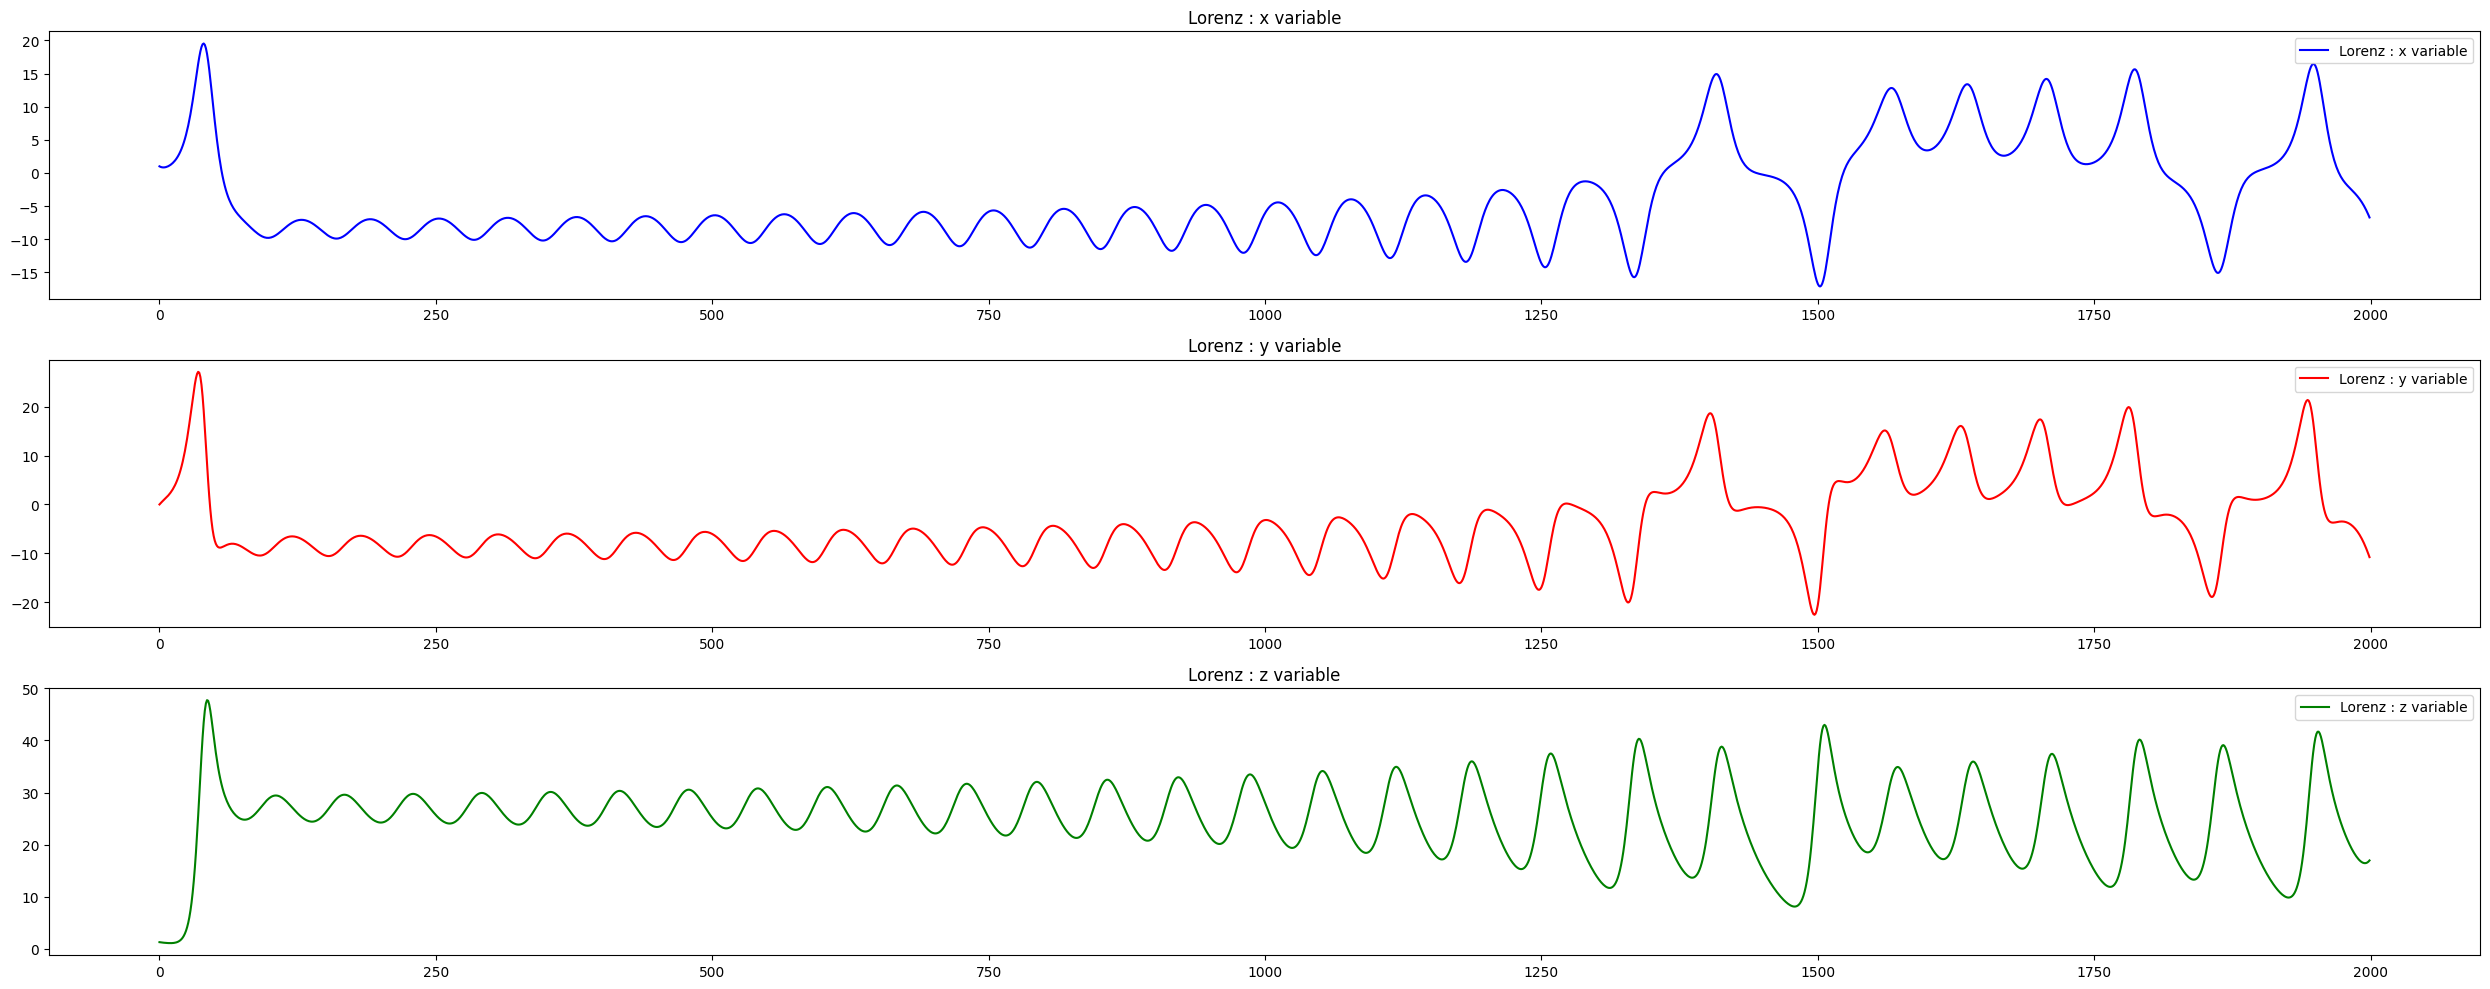

In [4]:
plotter_lorenz  =plottings.ChaoticSystemPlotter(data=lorenz_data, system_name='Lorenz')
plotter_lorenz.plot_all_trajectories(render='vertical')


## 3: Normalize the Lorenz Data

Before training, we normalize the Lorenz system outputs to improve convergence and stability.

- We use a custom `Normalization_Strategy` provided in `data_utils.preprocess`.
- `Scale_ToNormalize` performs **min-max scaling** or a domain-specific scaling with a custom `scaling_factor`.
- The function returns:
  - `scaled_lorenz`: normalized version of the data
  - `avg_lorenz`: average vector (useful for rescaling if needed)

We also truncate the dataset to the first 200 steps for a quicker training demo.


In [5]:
norma = preprocess.Normalization_Strategy()
scaled_lorenz, avg_lorenz = norma.Scale_ToNormalize(data=lorenz_data, scaling_factor=0.02)
scaled_lorenz = scaled_lorenz[:200]


print(scaled_lorenz.shape , avg_lorenz.shape)

torch.Size([200, 3]) torch.Size([3])


## 4: Split into Training and Testing Sets

To train and evaluate the model, we split the normalized data:

- **Training Set**: the first 150 timesteps
- **Testing Set**: the remaining 50 timesteps (used later for inference or visualization)

This is a simple chronological split suitable for time series forecasting tasks.


In [6]:
train_size = 150
train_lorenz = scaled_lorenz[:train_size]
test_lorenz = scaled_lorenz[train_size:]

print(train_lorenz.shape, test_lorenz.shape)


torch.Size([150, 3]) torch.Size([50, 3])


## Data Preparation for training purpose.

HCNN models can be trained using two different methods: fully unfolded and abriged training mode. Depending on each method we would like to train our models on, the preparation of the data will also change. 


## Fully unfolded mode

In this context, the size of the training set corresponds to the length of
the unfolded architecture, meaning that at each epoch, the HCNN is fed with
the entire (training) data sequence at once. 

During the forecast process, that
sequence is used as a calibration window, to which the TF mechanism is applied.
Then, the forecast operation takes place and the network is rolled into the future
direction until the desired forecast horizon is attained.
See the image below.

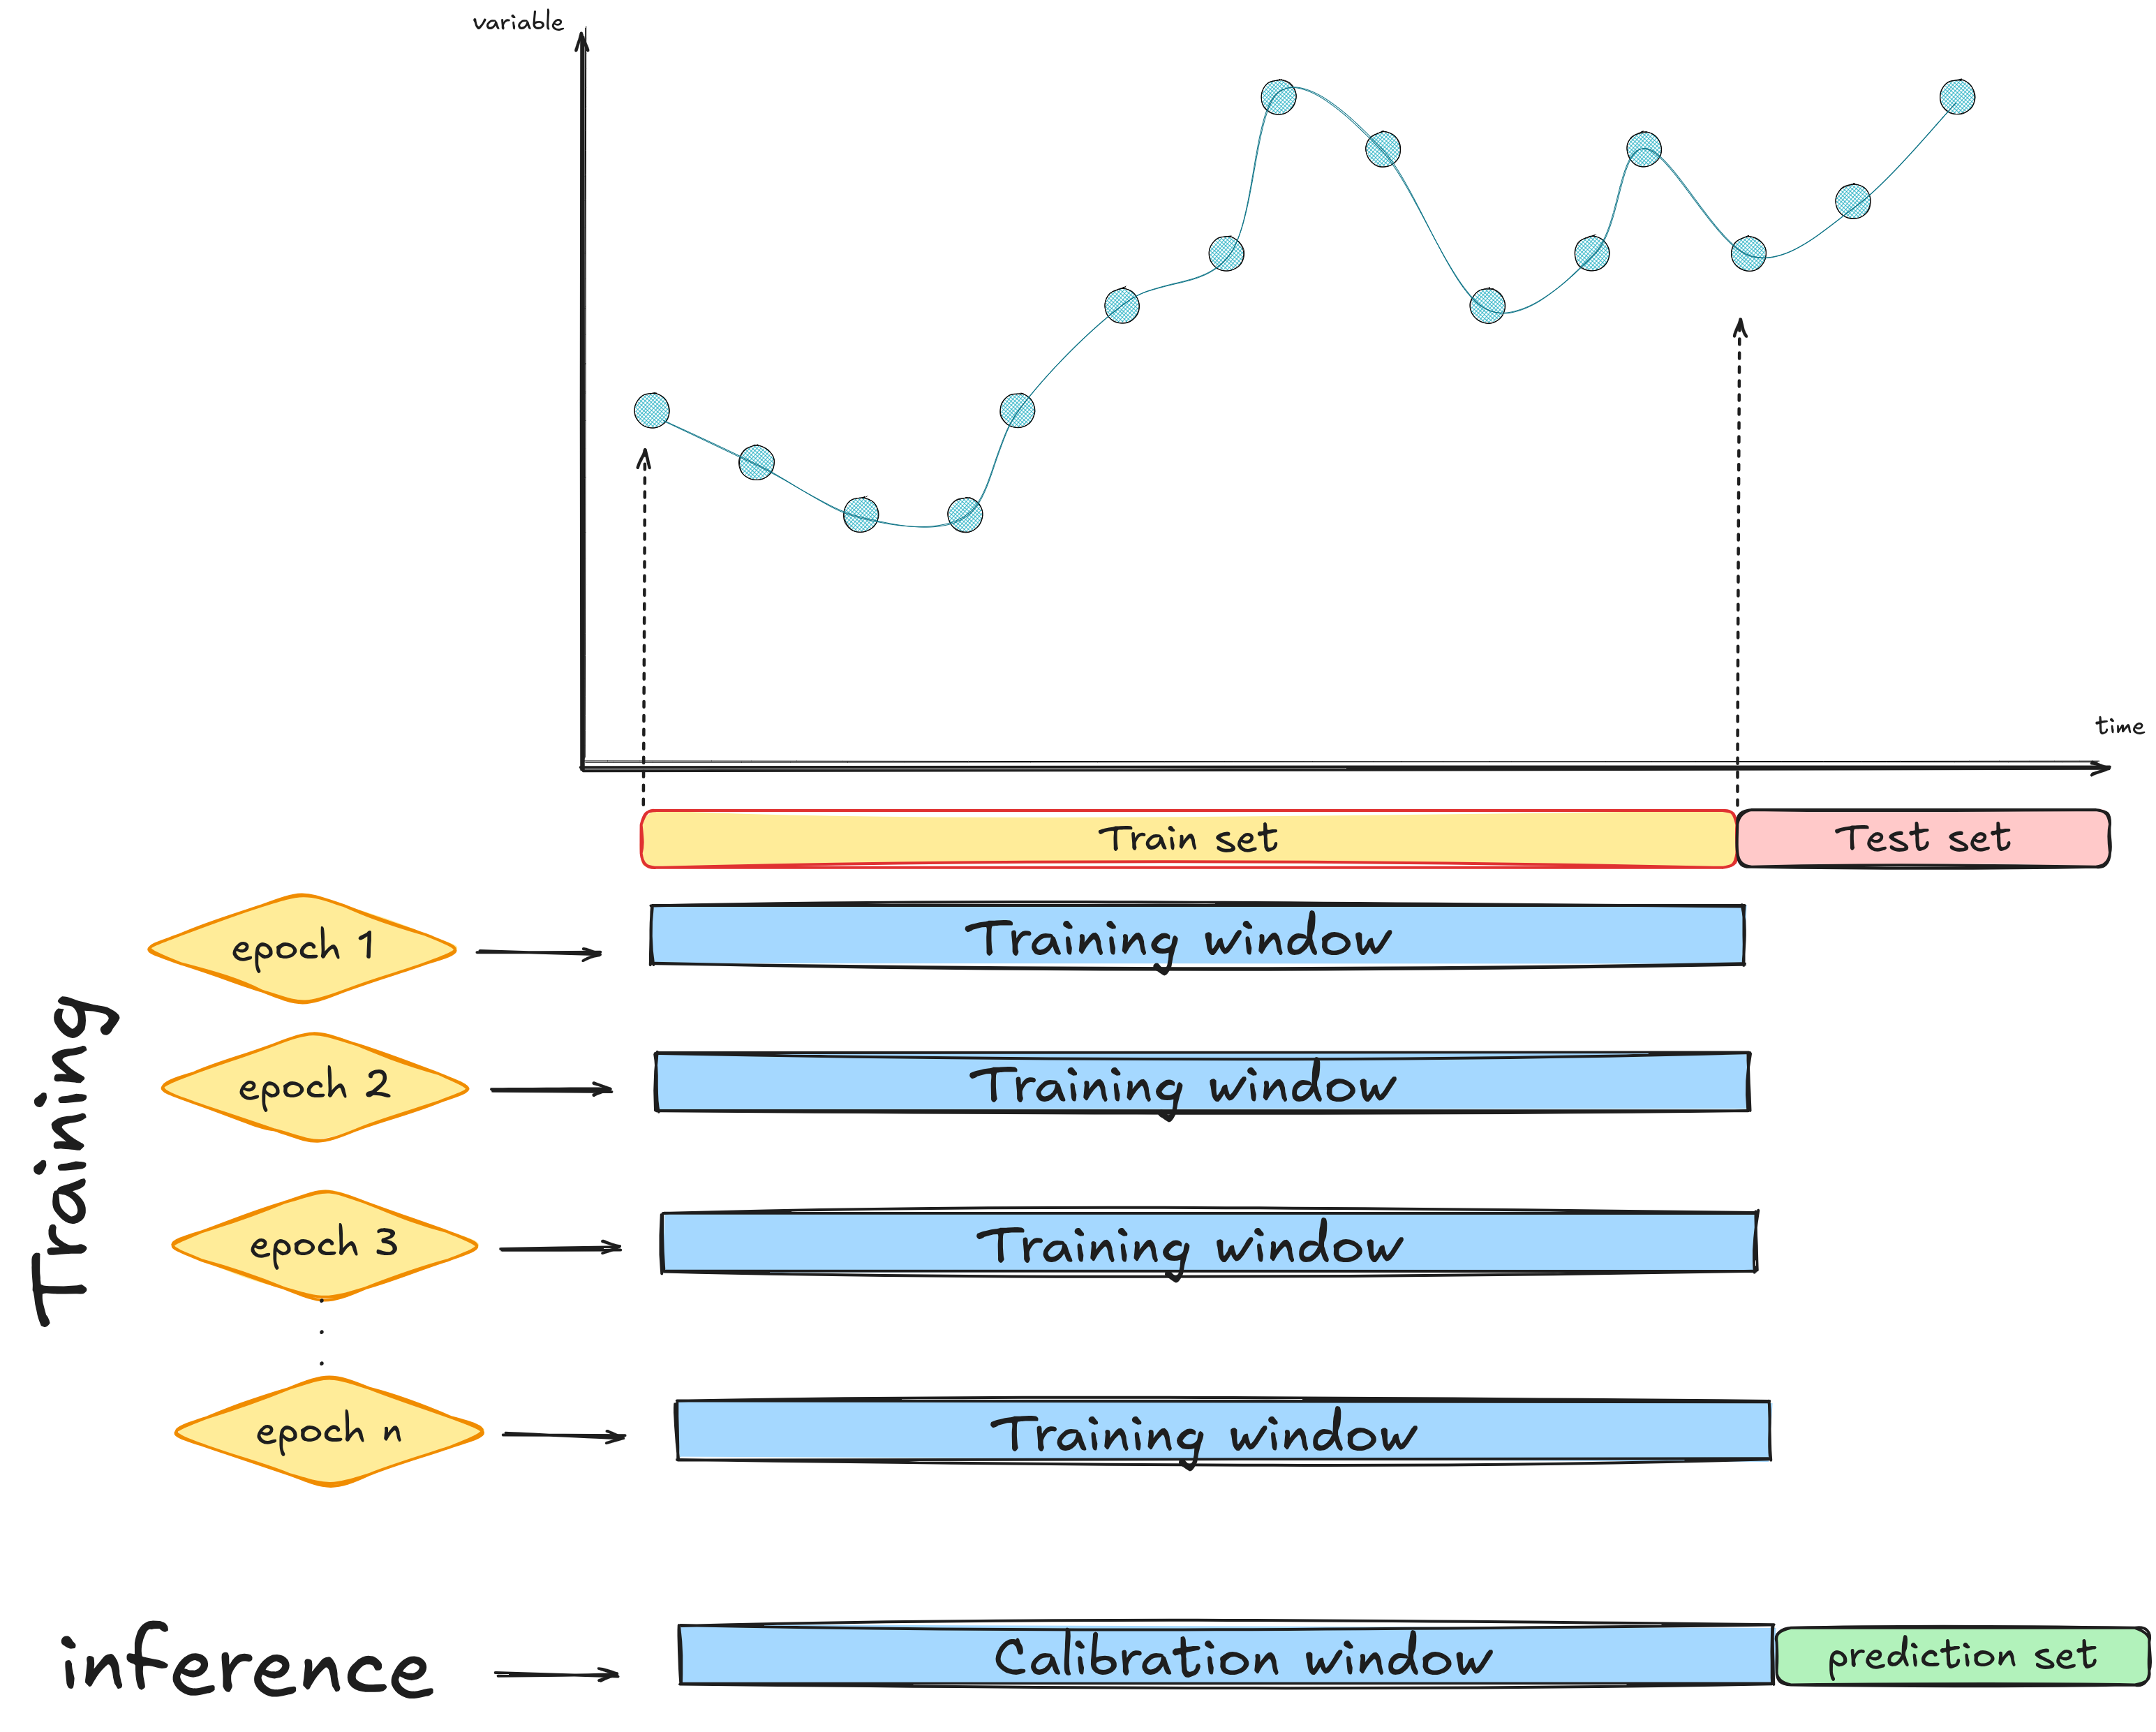

In [7]:
from IPython.display import Image


Image(filename='img_usage/fully_unfolded_mode.png' , width=600)

## Abridged mode

In this context, the training data is truncated and assembled into chunks
of the same size (an overlapping of chunks could be allowed during the assem-
bling stage). The HCNN
architecture then uses l as its fixed past unfolding length. The architecture is
trained on the (batches of) chunks, not necessarily in an ordered manner. At
forecast time, the last l chronological samples of the training data are retained
and used by the HCNN as a calibration window to which TF is applied and the forecasts are provided in the same fashion as in the fully unfolded mode.

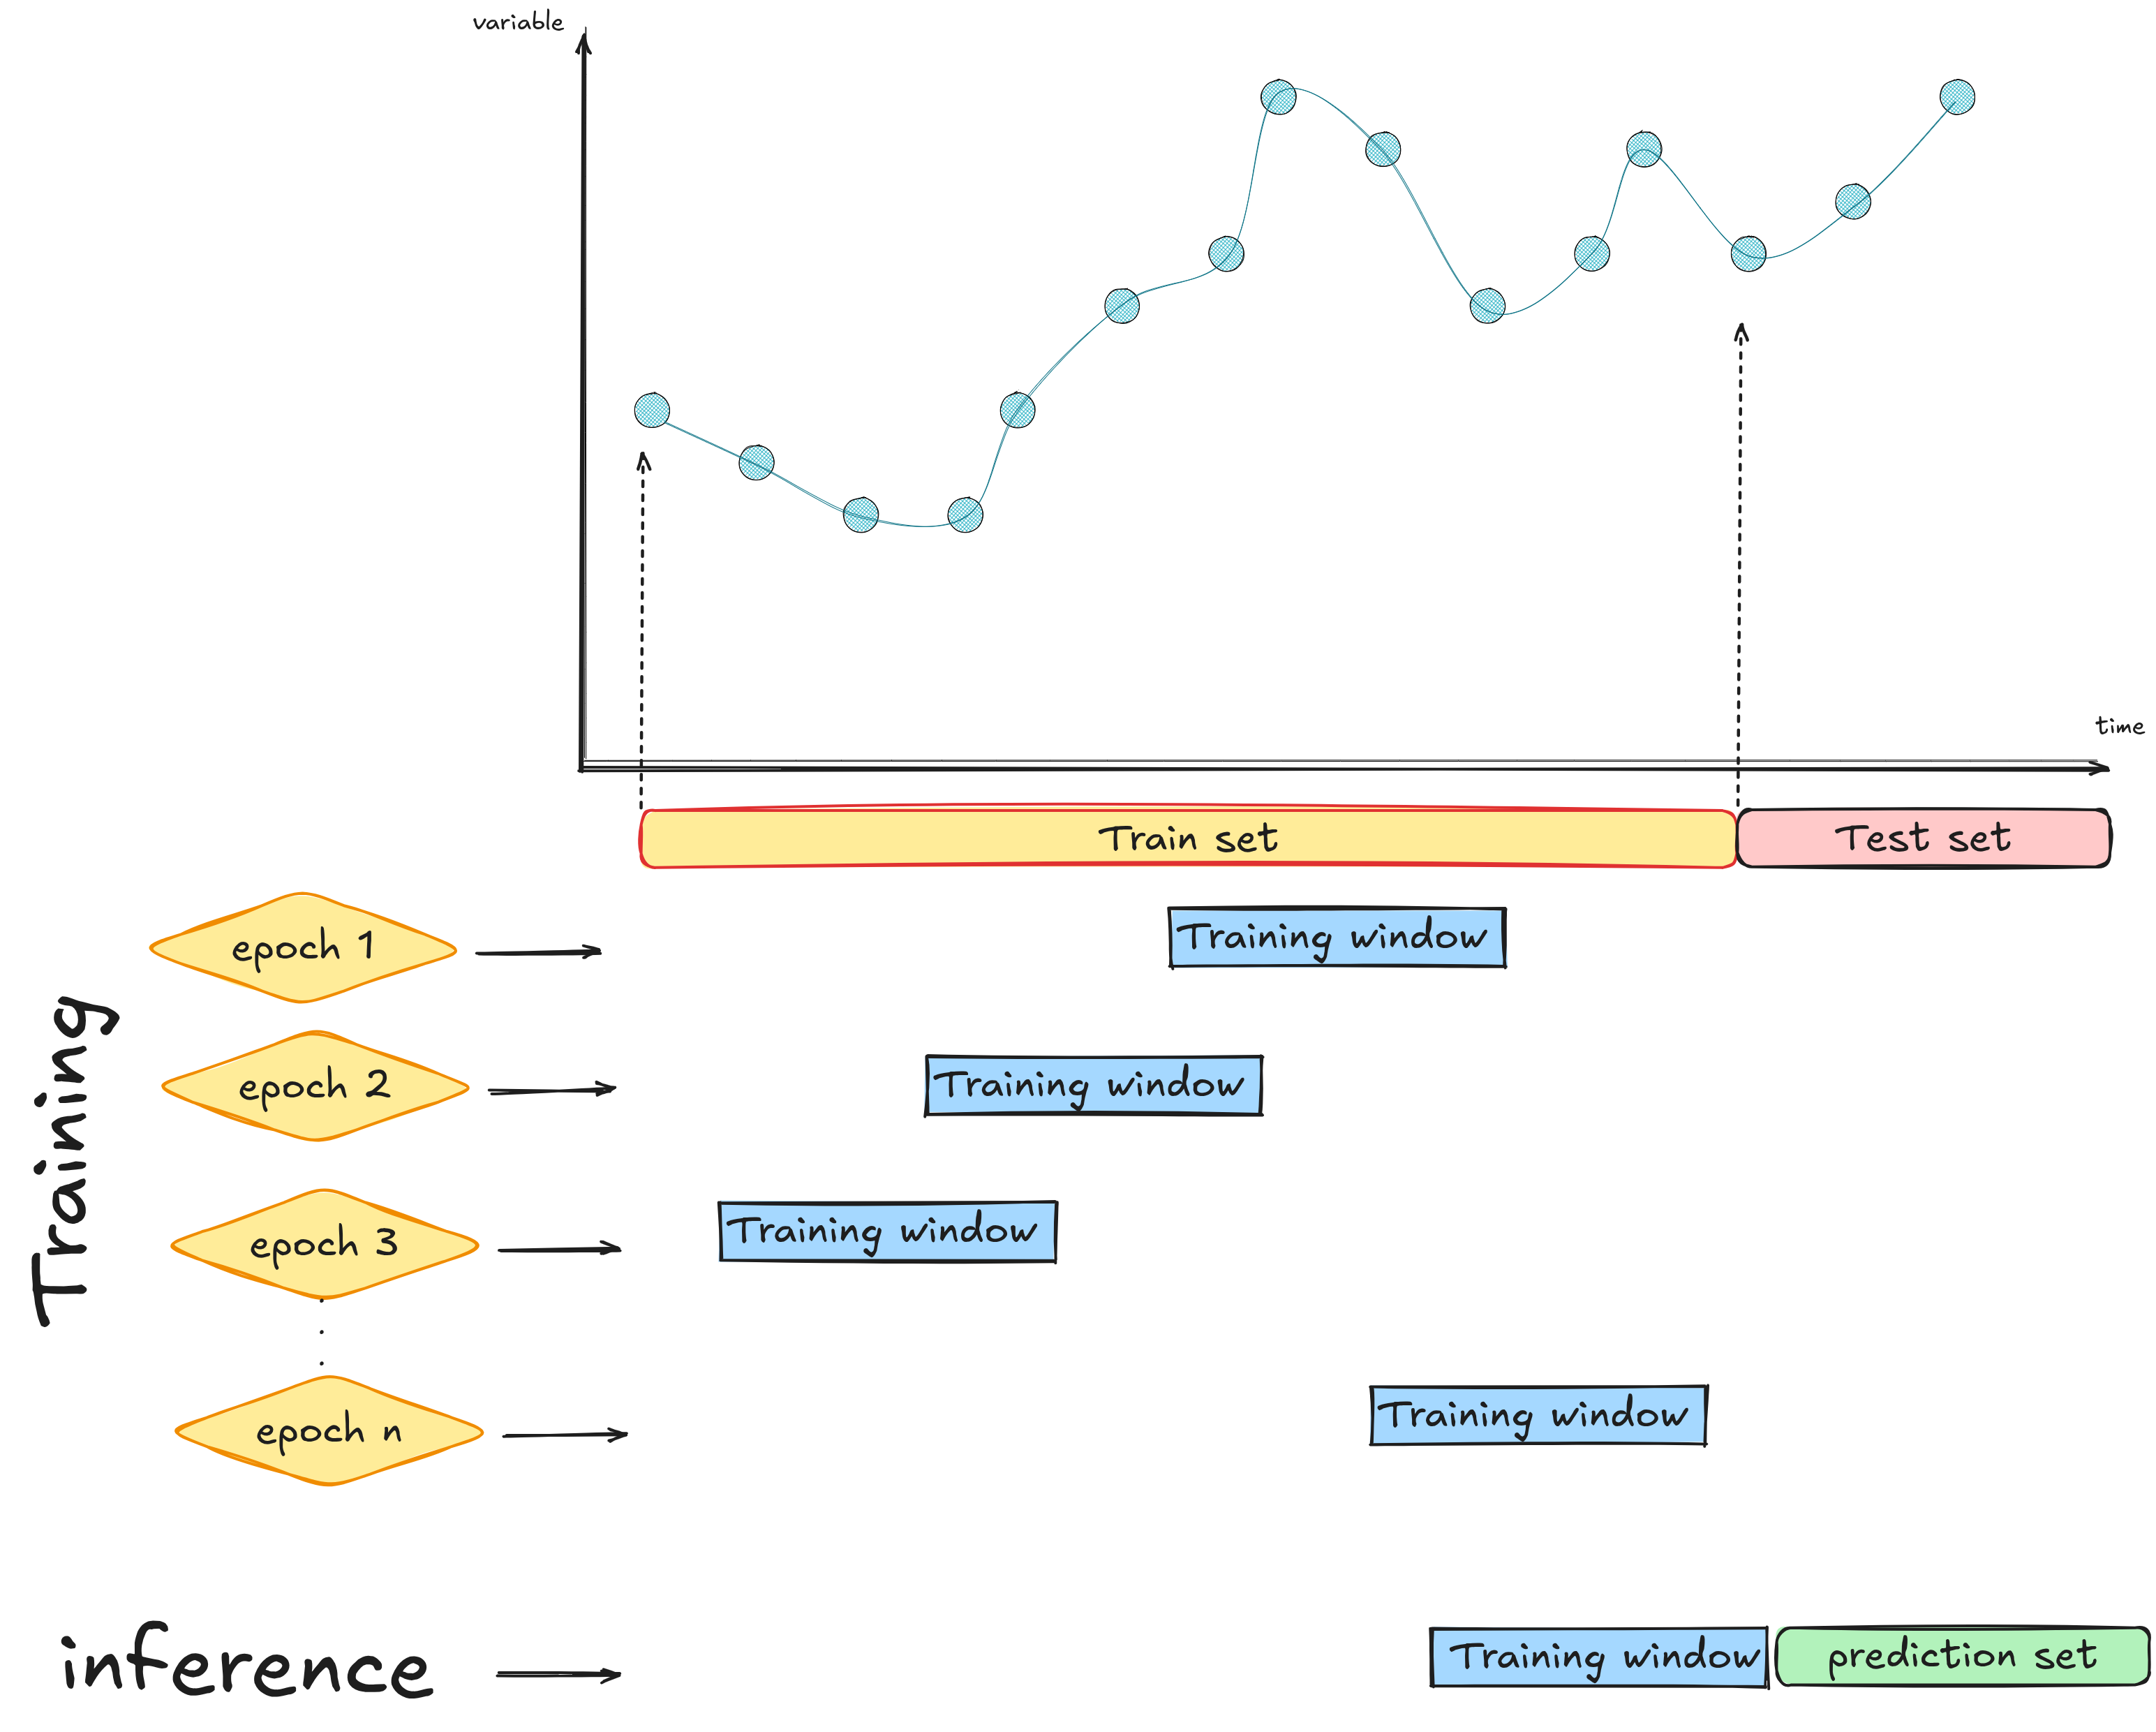

In [8]:
from IPython.display import Image


Image(filename='img_usage/abridged_mode.png' , width=600)

##  5: Create Sliding Windows and a DataLoader FOR FULLY UNFOLDED TRAINING MODE

To train HCNN models, we can either the fully unfolded or abridged training method. 

- `InpTarg_TSDataset.create_train_loader(...)`
  - Automatically wraps sliding windows into a PyTorch `DataLoader`
  - `window_size=10` creates input sequences of 10 timesteps
  - `batch_size=5` defines how many samples per batch



- `SlidingWindowDataset(...)` and the `sliding_windows_shift_to(...)` method
  - Also generate sliding windows directly as a NumPy/torch array
  - We pass in the data  and thbe window size which is the length of the training data

In [9]:

data_sliding_full_unf= preprocess.SlidingWindowDataset(data=train_lorenz, window_size=150)
sliced_data_full_unf = data_sliding_full_unf.sliding_windows_shift_to(train_lorenz, window_size=150)

print(sliced_data_full_unf.shape)   





torch.Size([1, 150, 3])


In [10]:
my_hcnn_full_unf_data_loader = preprocess.SlidingWindowDataLoader(dataset=sliced_data_full_unf, batch_size=1, shuffle=False)


##  6: Create Calibration and Forecast Windows

For validation and forecasting tasks, we need a **calibration window** (context) and the **ground-truth future** (target):

- `context_size`: how many past timesteps to use as model input
- `fcast_size`: how many future timesteps to forecast
- `location`:
  - `'random_'`: sample a random forecast segment
  - `'last_'`: use the last available portion of the time series

These sequences are used by the trainer during `train_validate()` or for manual forecasting evaluation.


In [11]:
full_data_sliding = preprocess.SlidingWindowDataset(data=scaled_lorenz, window_size=200)
# my_data_loader = data_sliding.sliding_windows_shift_to(train_lorenz, 150)

context_data_l, toforecast_data_l = full_data_sliding.contextwindow_testdata_generator(
    context_size=1, fcast_size=199, location='last_')

print(context_data_l.shape, toforecast_data_l.shape)

torch.Size([1, 3]) torch.Size([199, 3])


In this section, we instantiate an ensemble of `10` Vanilla HCNN members with the following configuratiions. 

* `n_ensemble = 10`: Specifies the number of HCNN ensemble members.

* `n_obs_vars = 3`: Specifies three observed variables.

* `n_hid_vars = 5`: Defines five hidden variables.

* `s0_nature='random_'`: Sets the initial hidden state values to random (alternative: `zeros_` for an all-zeros vector).

* `train_s0=True`: Makes the initial state vector trainable, allowing the weights of `s0` to be learned during training.

* `optimizer_type`: The type of optimizer that will be used for the training of each member.

* `learning_rate`: the learning rate used for the training of each member.

* `init_range=(-0.25, 0.25)`: Specifies the initialization range for the model's weight parameters.



In [12]:
from hcnns_chaos.core.ensembles.hcnn_ensembles import (VanillaHCNNEnsemble, PTFHCNNEnsemble as HCNNpTFEnsemble, LFormHCNNEnsemble as HCNNLFormEnsemble, LSpaHCNNEnsemble as LSpaEnsemble)

In [13]:
my_vanilla_ensemble = VanillaHCNNEnsemble( n_ensemble=10 , n_obs_vars= 3, n_hid_vars=5 ,
                                          
                                           s0_nature='random_', train_s0=True, init_range=(-.25, 0.25),
                                           
                                           optimizer_type='adam', learning_rate=1e-3)

We can view all the instantiated models via the **model** attribute of the `my_vanilla_ensemble` object.   

In [14]:
my_vanilla_ensemble.models

[{'member_1': Vanilla_Model(
    (cell): vanilla_cell(
      (A): CustomLinear(in_features=8, out_features=8, bias=False)
    )
  ),
  'optimizer_1': Adam (
  Parameter Group 0
      amsgrad: False
      betas: (0.9, 0.999)
      capturable: False
      differentiable: False
      eps: 1e-08
      foreach: None
      fused: None
      lr: 0.001
      maximize: False
      weight_decay: 0
  )},
 {'member_2': Vanilla_Model(
    (cell): vanilla_cell(
      (A): CustomLinear(in_features=8, out_features=8, bias=False)
    )
  ),
  'optimizer_2': Adam (
  Parameter Group 0
      amsgrad: False
      betas: (0.9, 0.999)
      capturable: False
      differentiable: False
      eps: 1e-08
      foreach: None
      fused: None
      lr: 0.001
      maximize: False
      weight_decay: 0
  )},
 {'member_3': Vanilla_Model(
    (cell): vanilla_cell(
      (A): CustomLinear(in_features=8, out_features=8, bias=False)
    )
  ),
  'optimizer_3': Adam (
  Parameter Group 0
      amsgrad: False
      be

##  Step 6: Model training

The `HCNNEnsembleTrainer` class offers two  training strategies: `train_only` and `train_and_validate`. 

- The `train_only` method focuses purely on minimizing training loss. It iterates over the training sequence(s) for a fixed number of epochs, tracks the average loss per epoch, and saves the model checkpoint corresponding to the lowest training loss encountered. This mode is particularly useful for quick model prototyping or when a separate validation set is not available. 

- In contrast, the `train_and_validate` method integrates both training and evaluation within each epoch. After each training pass, the model uses a defined calibration window to generate forecasts, which are then compared against a known future sequence (validation target). The model is checkpointed based on its validation performance, ensuring generalization is prioritized over memorization. 

The `backprop_mode` specifies which backpropagation mode will be used for the training of either each ensemble ini

### Configure the Vanilla HCNNEnsembleTrainer

We now set up the `HCNNEnsembleTrainer` to manage model training, loss computation, backpropagation, and checkpointing.

- `ensembles`: the  `Vanilla_Model`ensemble passed in as a list (using the `.models` attribute.)
- `loss_fn`: the error metric to be used. `"logcosh"` is more robust than MSE to outliers  and `"mse"` can also be used.
- `best_on`: 
  - `"median"`: save the best set of models based on the median error of the ensemble.
  - `"individual"`: save the best model based on individual error metric.

In [15]:
from hcnns_chaos.utils.ensemble_trainer import HCNNEnsembleTrainer

In [17]:
my_vanilla_ensemble_trainer = HCNNEnsembleTrainer(ensembles=my_vanilla_ensemble.models, loss_fn="logcosh", 
                                                  best_on='median')

### Train the Model (`train_only` mode)

We now train the model using the `train_only()` method:

- The model will learn exclusively from training data — no validation set is involved.
- It will run for **10 epochs**.

- The backprop_mode is set to `per_batch` indicating that backpropagation and  weights parameters update are performed after a batch is processed. 
An alternative is `per_epoch` which suggests that the backprop and weights parameters udpate take place only on an epoch basis.

- At the end of each epoch:
  - Training loss is computed and logged.
  - The model is saved **only if it improves** the average training loss.
- Output:
  - A directory under `./checkpoints_<model_name>_<timestamp>/` containing:
    - `best_train_avg_loss.pth`: the best model weights
    - `epoch_losses.json`: training loss per epoch in JSON format


In [ ]:
my_vanilla_ensemble_trainer.train_only(
    data_loader=my_hcnn_full_unf_data_loader, num_epochs=10, backprop_mode='per_batch')


## Partial Teacher Forcing Model

In this section, we train an ensemble of 5 `PTF_model` using the `train_and_validate` method. 
We use the following configuration:

* `n_ensemble = 5`: Specifies the number of HCNNpTF ensemble members.

* `n_obs_vars = 3`: Specifies three observed variables.

* `n_hid_vars = 5`: Defines five hidden variables.

* `s0_nature='random_'`: Sets the initial hidden state values to random (alternative: `zeros_` for an all-zeros vector).

* `train_s0=True`: Makes the initial state vector trainable, allowing the weights of `s0` to be learned during training.

* `init_range=(-0.5, 0.5)`: Specifies the initialization range for the model's weight parameters.

* `target_prob = 0.35`: specifies the target probability for the partial teacher forcing mechanism.

* `drop_output =False`: whether to drop the output after the partial teacher forcing is applied( when `False`, the dropout elements are included as part of the loss calculation.)


In [ ]:
my_ptf_ensemble = HCNNpTFEnsemble(n_ensemble=5, n_obs_vars=3, n_hid_vars=5,
                                      s0_nature='random_', train_s0=True, init_range=(-.25, 0.25),
                                        optimizer_type='adam', learning_rate=1e-3,
                                        target_prob=0.35, drop_output=False)

### Train with Validation (`train_validate` mode)

We now switch to instantiating an ensemble of `PTF_Model`s and and perform **training + validation** using the `train_validate()` method:

- The ensemble members trains on sliding-window training batches from `my_hcnn_data_loader`.
- After each epoch, it forecasts using:
  - `calibration_window`: a short historical window (`context_data_l`)
  - `val_data`: the ground-truth future to be predicted (`toforecast_data_l`)
- The trainer compares the forecast to the ground truth and computes validation loss.
- It saves the model if the validation performance improves.
- The backprop_mode is set to `per_epoch` indicating that backpropagation and  weights parameters update are performed on an epoch basis (unlike `per_batch` as
per the example above).

Output Artifacts:
- `best_val_avg_loss.pth`: model with the lowest validation loss
- `epoch_losses.json`: training and validation losses per epoch
- `forecast_results_epoch_*.csv`: predicted vs actual sequences for each epoch

In [ ]:
my_ptf_ensemble_trainer = HCNNEnsembleTrainer(ensembles=my_ptf_ensemble.models, loss_fn="mse",
                                                best_on='individual')

In [ ]:
my_ptf_ensemble_trainer.train_and_validate( data_loader=my_hcnn_full_unf_data_loader,  calibration_window=context_data_l,
                                             val_data=toforecast_data_l,  num_epochs=5 , 
                                             backprop_mode='per_epoch')

We go back to Step to prepare the data for training under abridged mode.

##  Step 5: Create Sliding Windows and a DataLoader FOR FULLY UNFOLDED TRAINING MODE

To train HCNN models, we can either the fully unfolded or abridged training method. 

- `InpTarg_TSDataset.create_train_loader(...)`
  - Automatically wraps sliding windows into a PyTorch `DataLoader`
  - `window_size=10` creates input sequences of 10 timesteps
  - `batch_size=5` defines how many samples per batch



- `SlidingWindowDataset(...)` and the `sliding_windows_shift_to(...)` method
  - Also generate sliding windows directly as a NumPy/torch array
  - We pass in the data  and thbe window size which is the length of the training data

We segment the time series into overlapping sequences using a sliding window approach. Here, we set the window size to 50 time steps."


In [ ]:

data_sliding_abr = preprocess.SlidingWindowDataset(data=train_lorenz, window_size=50)
sliced_data_abr = data_sliding_abr.sliding_windows_shift_to(train_lorenz, window_size=50)

print(sliced_data_abr.shape)   





In [ ]:
batch_size = 15
my_hcnn_abr_data_loader = preprocess.SlidingWindowDataLoader(dataset=sliced_data_abr, batch_size=batch_size, shuffle=False)

In [ ]:
for batch in my_hcnn_abr_data_loader:
    print(batch.shape)
    break

We can then extract a context window and its associated future observations.

The context window can be located randomly within the train set (random in the image below) or chosen to be carefully at the end of the train set for forecast purpose (last).



In [ ]:

from IPython.display import Image


Image(filename='img_usage/sliding_windows_usage.png')

For a randomly selected context window of length 50, this method generates the subsequent 10 time steps. This approach can be utilized during inference to evaluate the model's ability to leverage a calibration window for forecasting. For instance, it is useful to test the model accuracy to predict the subsequent time steps. given the initial conditions.The sliding window approach allows us to extract context windows and their associated future observations. This is particularly useful for forecasting tasks.


In [ ]:
calibration_window_length =50
forecast_window_length = 10

context_data_r, toforecast_data_r = data_sliding_abr.contextwindow_testdata_generator(
    context_size=calibration_window_length, fcast_size=forecast_window_length, location='random_'
)


print(context_data_r.shape, toforecast_data_r.shape)


The same logic applies when the location is `last`. "The same logic applies when the context window is located at the end of the training set for forecasting purposes."


In [ ]:

context_data_l, toforecast_data_l = data_sliding_abr.contextwindow_testdata_generator(
    context_size=1, fcast_size=60, location='last_'
)
print(context_data_l.shape, toforecast_data_l.shape)

In this section, we train an ensemble of 6 `LForm_Model`s  using `train_only` method and the `per_batch` backpropagation mode. 

* `n_ensemble = 6`: Specifies the number of LForm ensemble members.

* `n_obs_vars = 3`: Specifies three observed variables.

* `n_hid_vars = 5`: Defines five hidden variables.

* `s0_nature='random_'`: Sets the initial hidden state values to random (alternative: `zeros_` for an all-zeros vector).

* `train_s0=True`: Makes the initial state vector trainable, allowing the weights of `s0` to be learned during training.

* `init_range=(-0.5, 0.5)`: Specifies the initialization range for the model's weight parameters.

*  `init_diag`:  Initial value for the diagonal elements



In [ ]:
my_lform_ensemble = HCNNLFormEnsemble(n_ensemble=5, n_obs_vars=3, n_hid_vars=5,
                                        s0_nature='random_', train_s0=True, init_range=(-.25, 0.25),
                                        optimizer_type='adam', learning_rate=1e-3,
                                        init_diag=1.)

In [ ]:
lform_model = LForm_Model(n_obs_vars=3, n_hid_vars=5, s0_nature='random_', train_s0=True, init_diag=1.0,init_range=(-0.5, 0.5))

In [ ]:
my_lform_ensemble_trainer = HCNNEnsembleTrainer(ensembles=my_lform_ensemble.models, loss_fn="mse", best_on='individual')
                                                

In [ ]:
my_lform_ensemble_trainer.train_only(data_loader= my_hcnn_abr_data_loader, num_epochs=5, backprop_mode='per_batch')

In this section, we will instantiate an ensemble of  `LSpa_Model` members using the `random_block` sparsity mode and 25% or `sparsity_ratio`. We will use the `train_and_validate` method and the `per_batch` backpropagation mode. 



* `n_ensemble = 6`: Specifies the number of LSPa ensemble members.


* `n_obs_vars = 3`: Specifies three observed variables.

* `n_hid_vars = 5`: Defines five hidden variables.

* `s0_nature='random_'`: Sets the initial hidden state values to random (alternative: `zeros_` for an all-zeros vector).

* `train_s0=True`: Makes the initial state vector trainable, allowing the weights of `s0` to be learned during training.

* `init_range=(-0.5, 0.5)`: Specifies the initialization range for the model's weight parameters.

*  `mask_type`:  Type of sparsity pattern to apply in the weight matrix: `random_block` or `non_obs_block`

*  `sparsity_ratio` : Fraction of weights to be set to zero in the masked region.
m

In [ ]:
my_lspa_ensemble =  LSpaEnsemble(n_ensemble=5, n_obs_vars=3, n_hid_vars=5,
                                        s0_nature='random_', train_s0=True, init_range=(-.5, .5),
                                        mask_type='random_block', sparsity_ratio=0.25)

In [ ]:
my_lspa_ensemble_trainer = HCNNEnsembleTrainer(ensembles=my_lspa_ensemble.models, loss_fn="mse", best_on='individual')

In [ ]:
my_lspa_ensemble_trainer.train_and_validate(   data_loader=my_hcnn_abr_data_loader,   
                                            calibration_window=context_data_r,  val_data=toforecast_data_l, 
                                              num_epochs=5 ,
                                              backprop_mode='per_batch')

In the next section, we will instantiate the `LSpa_Model` members using the `non_obs_block` sparsity mode and 15% or `sparsity_ratio`. We will use the `train_and_validate` method and the `per_epoch` backpropagation mode. 

In [ ]:
my_lspa_nonobs_ensemble =  LSpaEnsemble(n_ensemble=5, n_obs_vars=3, n_hid_vars=5,
                                        s0_nature='random_', train_s0=True, init_range=(-.5, .5),
                                        mask_type='non_obs_block', sparsity_ratio=0.15)

In [ ]:
my_lspa_nonobs_ensemble_trainer = HCNNEnsembleTrainer(ensembles=my_lspa_nonobs_ensemble.models, loss_fn="mse", best_on='individual')

In [ ]:
my_lspa_nonobs_ensemble_trainer.train_and_validate(   data_loader=my_hcnn_abr_data_loader,   
                                            calibration_window=context_data_r,  val_data=toforecast_data_l, 
                                              num_epochs=5 ,
                                              backprop_mode='per_epoch')